# Data discovery & labeling
Last updated: _2022.06.08_

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
df_raw = pd.read_parquet("input/dps_2022_21_brandid_2300_301_for_candidates.parquet", dtype_backend="pyarrow")

In [3]:
df_raw = df_raw.replace('NA', pd.NA)

In [4]:
print("There are {:,} rows and {:} columns in the raw data.".format(df_raw.shape[0], df_raw.shape[1]))
print("The dataset contains data from {:} to {:}.".format(df_raw['summary_date'].min(), df_raw['summary_date'].max()))

There are 545,488 rows and 51 columns in the raw data.
The dataset contains data from 2021-01-01 to 2022-12-31.


## Column checks

In [ ]:
df_raw['accountid'].nunique()

In [ ]:
df_raw['accountid'].info()

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['registration_date'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Registration Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Registration Date', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [ ]:
df_raw['brandid'].value_counts()

In [ ]:
df_raw['agp_brand'].value_counts()

Check if brand_id is linked with agp_brand?

In [ ]:
# Check whether brandid and agp_brand are functionally linked
brand_to_agp = df_raw.groupby('brandid')['agp_brand'].nunique(dropna=False).sort_values(ascending=False)
agp_to_brand = df_raw.groupby('agp_brand')['brandid'].nunique(dropna=False).sort_values(ascending=False)

print(f"Each brandid maps to a single agp_brand: {(brand_to_agp <= 1).all()}")
print(f"Each agp_brand maps to a single brandid: {(agp_to_brand <= 1).all()}")

ambiguous_brand_ids = brand_to_agp[brand_to_agp > 1]
ambiguous_agp_brands = agp_to_brand[agp_to_brand > 1]

print(f"brandid values linked to multiple agp_brand values: {len(ambiguous_brand_ids)}")
print(f"agp_brand values linked to multiple brandid values: {len(ambiguous_agp_brands)}")

if not ambiguous_brand_ids.empty:
    display(
        df_raw[df_raw['brandid'].isin(ambiguous_brand_ids.index)]
        [['brandid', 'agp_brand']]
        .drop_duplicates()
        .sort_values(['brandid', 'agp_brand'])
        .head(25)
    )

if not ambiguous_agp_brands.empty:
    display(
        df_raw[df_raw['agp_brand'].isin(ambiguous_agp_brands.index)]
        [['agp_brand', 'brandid']]
        .drop_duplicates()
        .sort_values(['agp_brand', 'brandid'])
        .head(25)
    )

In [ ]:
df_raw['reporting_region'].value_counts()

In [ ]:
df_raw['market'].value_counts()

In [ ]:
df_raw['reg_channel'].value_counts(dropna=False)

In [ ]:
df_raw['reg_channel'].describe()

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['firstdeposit_createddate'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('First Deposit Created Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of First Deposit Created Date', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [ ]:
df_raw['reg_prod'].value_counts()

In [ ]:
df_raw['foundation_category'].value_counts()

In [ ]:
df_raw['account_tier'].value_counts()

In [ ]:
df_raw['ordinalposition'].value_counts()

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['summary_date'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Summary Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Summary Date', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [ ]:
df_raw['category'].value_counts()

In [ ]:
df_raw['activity_channel'].value_counts()

In [ ]:
df_raw['secondary_product'].value_counts()[:10]

In [ ]:
df_raw['bet_type'].value_counts()

In [ ]:
df_raw['productgroup'].value_counts()

In [ ]:
df_raw['plc_turnover_gbp'].value_counts()

In [ ]:
df_raw['plc_turnover'].value_counts()

In [ ]:
df_raw[df_raw['plc_turnover_gbp'] != df_raw['plc_turnover']][['plc_turnover_gbp', 'plc_turnover']]

In [ ]:
df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'].mean(), df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'].mean()

In [ ]:
df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'].median(), df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'].median()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('PLC turnover (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of PLC turnover (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'].mean()
median_progress = df_raw[df_raw['plc_turnover_gbp'] > 0]['plc_turnover_gbp'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('PLC turnover', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of PLC turnover', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'].mean()
median_fill = df_raw[df_raw['plc_turnover'] > 0]['plc_turnover'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['plc_turnover_gbp_rcash'] > 0]['plc_turnover_gbp_rcash'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('RCash (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of RCash (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['plc_turnover_gbp_rcash'] > 0]['plc_turnover_gbp_rcash'].mean()
median_progress = df_raw[df_raw['plc_turnover_gbp_rcash'] > 0]['plc_turnover_gbp_rcash'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['plc_turnover_rcash'] > 0]['plc_turnover_rcash'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('RCash', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of RCash', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['plc_turnover_rcash'] > 0]['plc_turnover_rcash'].mean()
median_fill = df_raw[df_raw['plc_turnover_rcash'] > 0]['plc_turnover_rcash'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['plc_turnover_gbp_bonus'] > 0]['plc_turnover_gbp_bonus'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('Bonus (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Bonus (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['plc_turnover_gbp_bonus'] > 0]['plc_turnover_gbp_bonus'].mean()
median_progress = df_raw[df_raw['plc_turnover_gbp_bonus'] > 0]['plc_turnover_gbp_bonus'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['plc_turnover_bonus'] > 0]['plc_turnover_bonus'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Bonus', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Bonus', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['plc_turnover_bonus'] > 0]['plc_turnover_bonus'].mean()
median_fill = df_raw[df_raw['plc_turnover_bonus'] > 0]['plc_turnover_bonus'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['plc_betcount'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Bet Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Bet Count', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_turnover_gbp'] > 0]['stl_turnover_gbp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL Turnover (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL Turnover (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_turnover_gbp'] > 0]['stl_turnover_gbp'].mean()
median_progress = df_raw[df_raw['stl_turnover_gbp'] > 0]['stl_turnover_gbp'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_turnover'] > 0]['stl_turnover'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL Turnover', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL Turnover', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_turnover'] > 0]['stl_turnover'].mean()
median_fill = df_raw[df_raw['stl_turnover'] > 0]['stl_turnover'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_turnover_gbp_rcash'] > 0]['stl_turnover_gbp_rcash'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL Turnover RCash (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL Turnover RCash (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_turnover_gbp_rcash'] > 0]['stl_turnover_gbp_rcash'].mean()
median_progress = df_raw[df_raw['stl_turnover_gbp_rcash'] > 0]['stl_turnover_gbp_rcash'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_turnover_rcash'] > 0]['stl_turnover_rcash'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL Turnover RCash', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL Turnover RCash', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_turnover_rcash'] > 0]['stl_turnover_rcash'].mean()
median_fill = df_raw[df_raw['stl_turnover_rcash'] > 0]['stl_turnover_rcash'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_turnover_gbp_bonus'] > 0]['stl_turnover_gbp_bonus'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL Turnover Bonus (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL Turnover Bonus (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_turnover_gbp_bonus'] > 0]['stl_turnover_gbp_bonus'].mean()
median_progress = df_raw[df_raw['stl_turnover_gbp_bonus'] > 0]['stl_turnover_gbp_bonus'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_turnover_bonus'] > 0]['stl_turnover_bonus'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL Turnover Bonus', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL Turnover Bonus', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_turnover_bonus'] > 0]['stl_turnover_bonus'].mean()
median_fill = df_raw[df_raw['stl_turnover_bonus'] > 0]['stl_turnover_bonus'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL GGR (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL GGR (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'].mean()
median_progress = df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL GGR (GBP)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL GGR (GBP)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'].mean()
median_fill = df_raw[df_raw['stl_ggr_gbp'] > 0]['stl_ggr_gbp'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_ggr_gbp_rcash'] > 0]['stl_ggr_gbp_rcash'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL GGR RCash (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL GGR RCash (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_ggr_gbp_rcash'] > 0]['stl_ggr_gbp_rcash'].mean()
median_progress = df_raw[df_raw['stl_ggr_gbp_rcash'] > 0]['stl_ggr_gbp_rcash'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_ggr_rcash'] > 0]['stl_ggr_rcash'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL GGR RCash', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL GGR RCash', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_ggr_rcash'] > 0]['stl_ggr_rcash'].mean()
median_fill = df_raw[df_raw['stl_ggr_rcash'] > 0]['stl_ggr_rcash'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['stl_ggr_gbp_bonus'] > 0]['stl_ggr_gbp_bonus'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('STL GGR Bonus (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of STL GGR Bonus (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['stl_ggr_gbp_bonus'] > 0]['stl_ggr_gbp_bonus'].mean()
median_progress = df_raw[df_raw['stl_ggr_gbp_bonus'] > 0]['stl_ggr_gbp_bonus'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['stl_ggr_bonus'] > 0]['stl_ggr_bonus'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('STL GGR Bonus', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of STL GGR Bonus', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['stl_ggr_bonus'] > 0]['stl_ggr_bonus'].mean()
median_fill = df_raw[df_raw['stl_ggr_bonus'] > 0]['stl_ggr_bonus'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
df_raw['stl_betting_duty'].value_counts()

In [ ]:
df_raw['stl_licence_fee'].value_counts()

In [ ]:
df_raw['stl_tax'].value_counts()

In [ ]:
df_raw['stl_partnerfee'].value_counts()

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['stl_betcount'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Bet Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of STL Bet Count', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['deposit'] > 0]['deposit'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('Deposit (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Deposit (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['deposit'] > 0]['deposit'].mean()
median_progress = df_raw[df_raw['deposit'] > 0]['deposit'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['deposit_gbp'] > 0]['deposit_gbp'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Deposit GGR Bonus (GBP)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Deposit GGR Bonus (GBP)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['deposit_gbp'] > 0]['deposit_gbp'].mean()
median_fill = df_raw[df_raw['deposit_gbp'] > 0]['deposit_gbp'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['withdrawal_gbp'] > 0]['withdrawal_gbp'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('Withdrawal (GBP)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Withdrawal (GBP)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['withdrawal_gbp'] > 0]['withdrawal_gbp'].mean()
median_progress = df_raw[df_raw['withdrawal_gbp'] > 0]['withdrawal_gbp'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['withdrawal'] > 0]['withdrawal'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Withdrawal', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Withdrawal)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['withdrawal'] > 0]['withdrawal'].mean()
median_fill = df_raw[df_raw['withdrawal'] > 0]['withdrawal'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['bonus_costs'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Bonus Costs', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Bonus Costs', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['realcash_costs'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Real Cash Costs', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Real Cash Costs', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [ ]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['bonusfunds_costs'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Bonus Funds Costs', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Bonus Funds Costs', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# First histogram
ax1.hist(df_raw[df_raw['bonus_costs_accurrency'] > 0]['bonus_costs_accurrency'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax1.set_xlabel('Bonus Costs', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Bonus Costs', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
mean_progress = df_raw[df_raw['bonus_costs_accurrency'] > 0]['bonus_costs_accurrency'].mean()
median_progress = df_raw[df_raw['bonus_costs_accurrency'] > 0]['bonus_costs_accurrency'].median()
ax1.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax1.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax1.legend()

# Second histogram
ax2.hist(df_raw[df_raw['bonus_costs_accurrency'] > 0]['bonus_costs_accurrency'], bins=30, color='coral', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Bonus Funds Costs', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Bonus Funds Costs', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics
mean_fill = df_raw[df_raw['bonus_costs_accurrency'] > 0]['bonus_costs_accurrency'].mean()
median_fill = df_raw[df_raw['bonus_costs_accurrency'] > 0]['bonus_costs_accurrency'].median()
ax2.axvline(mean_fill, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fill:.4f}')
ax2.axvline(median_fill, color='green', linestyle='--', linewidth=2, label=f'Median: {median_fill:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

## Finding inactive users

In [5]:
df_raw['accountid'].nunique()

2000

At present, the retention teams are only able to use inaccurate heuristics for this targeting, notably looking for __customers__ that have been __inactive for 28 days__. This is too late: there is more friction for a returning customer than a still-active one. Moreover, since there are so many false positives, the ‘return’ on retention tactics is lower, pushing the retention teams towards cheaper and less effective measures.

To improve this situation, the Data Science team has been asked to formulate a churn-prediction model to allow more accurate retention targeting whilst the customer remains active (i.e. placing bets). Your challenge is to build a proof-of-concept using the data provided to you.

In [6]:
df_raw['accountid'].unique().tolist()[:5]

[667707849, 667574815, 667338216, 667183293, 667037144]

In [7]:
df_raw_grouped = df_raw[['accountid', 'registration_date']].groupby('accountid').agg({
    'accountid': 'count'
}).rename(columns={'accountid': 'record_count'}).reset_index()

In [8]:
df_raw_grouped.sort_values('record_count', ascending=False, inplace=True)

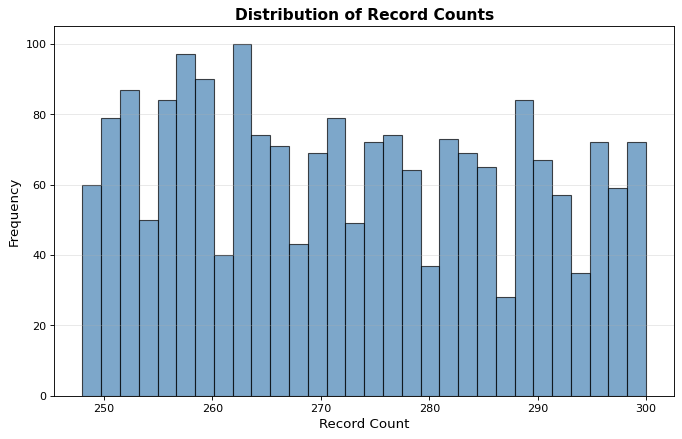

In [9]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw_grouped['record_count'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=False)
ax.set_xlabel('Record Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Record Counts', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

In [10]:
df_raw[df_raw['accountid'] == 667707849][df_raw.columns.tolist()[:15]][:10]

,accountid,registration_date,brandid,agp_brand,reporting_region,market,reg_channel,firstdeposit_createddate,reg_prod,foundation_category,account_tier,ordinalposition,summary_date,category,activity_channel
0,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,NEW,10,2021-07-19,<NA>,<NA>
103,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,NEW,10,2021-07-19,eGaming,Not Available
1269,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,NEW WATCH LIST,11,2021-07-29,eGaming,<NA>
1402,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-09-11,<NA>,<NA>
1429,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-09-11,Sports,<NA>
1743,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-09-11,Sports,Desktop
1777,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-09-11,eGaming,Not Available
2876,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-08-26,<NA>,<NA>
2890,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-08-26,eGaming,<NA>
2975,667707849,2021-07-17,2300,Parimatch UK,United Kingdom,Parimatch UK,Mobile,2021-07-17,Sports,NewPlayer,AVERAGE,6,2021-08-26,eGaming,Not Available


In [11]:
df_raw_summary_date_grouped = df_raw[['accountid', 'summary_date']].groupby('accountid').agg({
    'summary_date': ['count', 'nunique']
}).droplevel(0, axis=1).rename(columns={'accountid': 'record_count'}).reset_index()

In [12]:
df_raw_summary_date_grouped[:5]

,accountid,count,nunique
0,666989420,265,197
1,666989923,273,130
2,666990238,262,113
3,666999616,267,120
4,667005177,289,106


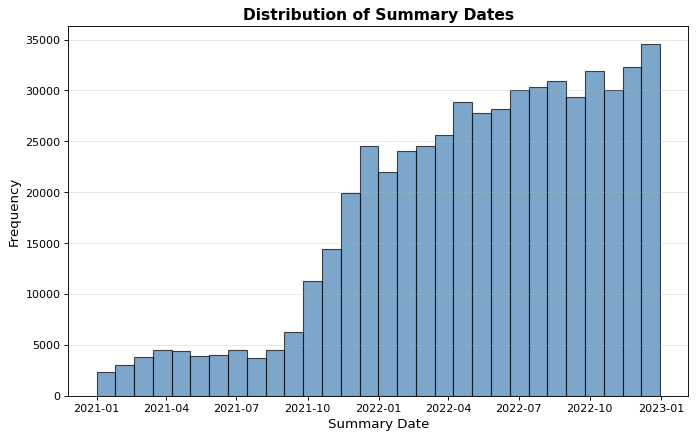

In [13]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_raw['summary_date'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=False)
ax.set_xlabel('Summary Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Summary Dates', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

Validate that every `summary_date` is represented by either a __minimum of one entry__ or __at least one activity__.

In [14]:
from pandas.api.types import is_numeric_dtype

# Interpret the hypothesis as:
# for each (accountid, summary_date) pair there is either exactly one row,
# or, if there are multiple rows, at least one of them contains activity.

account_col = 'accountid'
date_col = 'summary_date'

analysis_df = df_raw.copy()
analysis_df[date_col] = pd.to_datetime(analysis_df[date_col], errors='coerce')
analysis_df = analysis_df.dropna(subset=[account_col, date_col]).copy()

exclude_numeric_cols = {
    account_col,
    'brandid',
    'ordinalposition'
}
name_hints = (
    'turnover', 'betcount', 'bet_', 'ggr', 'deposit', 'withdrawal',
    'bonus', 'cost', 'fee', 'tax', 'duty', 'stake', 'activity'
)

activity_cols = []
for col in analysis_df.columns:
    if col in exclude_numeric_cols or not is_numeric_dtype(analysis_df[col]):
        continue

    series = analysis_df[col].fillna(0)
    has_non_zero_values = series.ne(0).any()
    looks_like_activity = any(hint in col.lower() for hint in name_hints)

    if has_non_zero_values and looks_like_activity:
        activity_cols.append(col)

if not activity_cols:
    raise ValueError('No numeric activity columns were detected automatically.')

analysis_df['has_activity'] = analysis_df[activity_cols].fillna(0).ne(0).any(axis=1)

pair_summary = (
    analysis_df.groupby([account_col, date_col])
    .agg(
        row_count=('has_activity', 'size'),
        active_row_count=('has_activity', 'sum')
    )
    .reset_index()
)

pair_summary['has_duplicate_rows'] = pair_summary['row_count'] > 1
pair_summary['supports_hypothesis'] = (
    (pair_summary['row_count'] == 1)
    | ((pair_summary['row_count'] > 1) & (pair_summary['active_row_count'] > 0))
)

duplicate_pairs = pair_summary[pair_summary['has_duplicate_rows']].copy()
violations = pair_summary[~pair_summary['supports_hypothesis']].copy()

print(f"Detected {len(activity_cols)} activity columns.")
print(f"Unique accounts: {analysis_df[account_col].nunique():,}")
print(f"Unique (accountid, summary_date) pairs: {len(pair_summary):,}")
print(f"Pairs with duplicate rows: {len(duplicate_pairs):,}")
print(f"Pairs violating the hypothesis: {len(violations):,}")

if violations.empty:
    print('\nResult: the hypothesis holds under this interpretation.')
else:
    print('\nResult: the hypothesis does not hold under this interpretation.')
    display(
        violations
        .sort_values(['row_count', 'active_row_count'], ascending=[False, False])
        .head(20)
    )

Detected 29 activity columns.
Unique accounts: 2,000
Unique (accountid, summary_date) pairs: 248,001
Pairs with duplicate rows: 196,973
Pairs violating the hypothesis: 0

Result: the hypothesis holds under this interpretation.


In [15]:
df_raw[df_raw['accountid'] == 667707849][df_raw.columns.tolist()[:15]][['accountid', 'summary_date', 'ordinalposition', 'account_tier', 'category', 'activity_channel']][:25]

,accountid,summary_date,ordinalposition,account_tier,category,activity_channel
0,667707849,2021-07-19,10,NEW,<NA>,<NA>
103,667707849,2021-07-19,10,NEW,eGaming,Not Available
1269,667707849,2021-07-29,11,NEW WATCH LIST,eGaming,<NA>
1402,667707849,2021-09-11,6,AVERAGE,<NA>,<NA>
1429,667707849,2021-09-11,6,AVERAGE,Sports,<NA>
1743,667707849,2021-09-11,6,AVERAGE,Sports,Desktop
1777,667707849,2021-09-11,6,AVERAGE,eGaming,Not Available
2876,667707849,2021-08-26,6,AVERAGE,<NA>,<NA>
2890,667707849,2021-08-26,6,AVERAGE,eGaming,<NA>
2975,667707849,2021-08-26,6,AVERAGE,eGaming,Not Available


In [16]:
df_summary_dates = df_raw[['accountid', 'summary_date']].sort_values(['accountid', 'summary_date'], ascending=True).copy()
df_summary_dates['summary_date'] = pd.to_datetime(df_summary_dates['summary_date'], errors='coerce')
df_summary_dates['summary_date_difference'] = (
    df_summary_dates.groupby('accountid')['summary_date']
    .diff()
    .dt.days
)

In [17]:
# Longest gap between summary dates for the same account
df_summary_dates[df_summary_dates['summary_date_difference'] == 450]

,accountid,summary_date,summary_date_difference
66946,667172357,2022-11-24,450.0


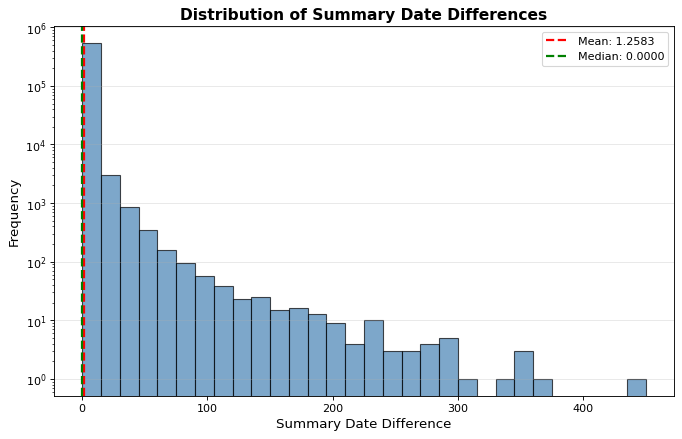

In [18]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_summary_dates['summary_date_difference'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Summary Date Difference', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Summary Date Differences', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

mean_progress = df_summary_dates['summary_date_difference'].mean()
median_progress = df_summary_dates['summary_date_difference'].median()
ax.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax.legend()

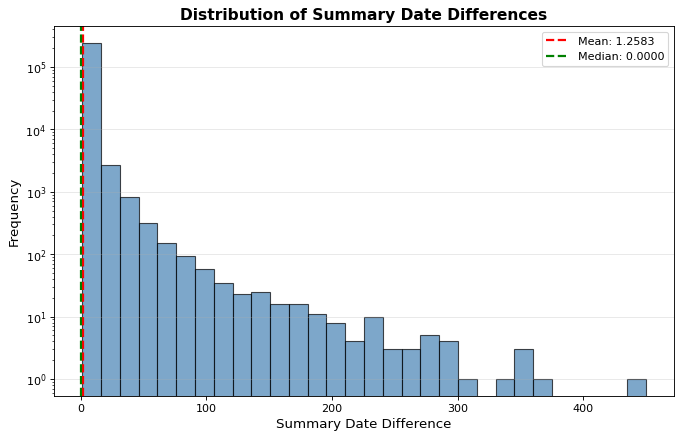

In [19]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(df_summary_dates[df_summary_dates['summary_date_difference'] > 0]['summary_date_difference'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Summary Date Difference', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Summary Date Differences', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

mean_progress = df_summary_dates['summary_date_difference'].mean()
median_progress = df_summary_dates['summary_date_difference'].median()
ax.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax.legend()

In [20]:
df_summary_dates[df_summary_dates['summary_date_difference'] > 0]['summary_date_difference'].mean(), df_summary_dates[df_summary_dates['summary_date_difference'] > 0]['summary_date_difference'].max()

(np.float64(2.779883008605656), np.float64(450.0))

In [21]:
df_raw[['ordinalposition', 'account_tier']].value_counts(dropna=False)    

ordinalposition  account_tier  
3                VALUED            261129
2                Premium           137744
4                MEDIUM             33050
10               NEW                25800
9                WINNERS            20486
6                AVERAGE            18353
7                LOW                17835
5                ABOVE AVERAGE      12601
8                LOWEST              9953
12               NO VALUE            4023
11               NEW WATCH LIST      2722
13               NON DEPOSITOR       1727
14               CLOSED                65
Name: count, dtype: int64

`ordinalpostition` is linked with `account_tier`

### Activity fields

In [22]:
# I suppose the following columns likely represent some form of "activity" based on their names and values
activity_columns = ['bet_type', 'productgroup', 'plc_turnover_gbp', 'plc_turnover',
       'plc_turnover_gbp_rcash', 'plc_turnover_rcash',
       'plc_turnover_gbp_bonus', 'plc_turnover_bonus', 'plc_betcount',
       'stl_turnover_gbp', 'stl_turnover', 'stl_turnover_gbp_rcash',
       'stl_turnover_rcash', 'stl_turnover_gbp_bonus', 'stl_turnover_bonus',
       'stl_ggr_gbp', 'stl_ggr', 'stl_ggr_gbp_rcash', 'stl_ggr_rcash',
       'stl_ggr_gbp_bonus', 'stl_ggr_bonus', 'stl_betting_duty',
       'stl_licence_fee', 'stl_tax', 'stl_partnerfee', 'stl_betcount',
       'deposit', 'deposit_gbp', 'withdrawal', 'withdrawal_gbp', 'bonus_costs',
       'realcash_costs', 'bonusfunds_costs', 'bonus_costs_accurrency',
       'bonusfunds_costs_accurrency']

In [23]:
df_raw[df_raw['accountid'] == 667172357][['accountid', 'summary_date', 'bet_type',
       'category', 'secondary_product', 
       'plc_betcount', 'stl_betcount']].sort_values('summary_date', ascending=False).head(20)

,accountid,summary_date,bet_type,category,secondary_product,plc_betcount,stl_betcount
412620,667172357,2022-12-29,<NA>,<NA>,<NA>,0E-9,0E-9
412669,667172357,2022-12-29,Single,Sports,Horse Racing,6.000000000,6.000000000
412672,667172357,2022-12-29,Combi,Sports,Horse Racing,2.000000000,2.000000000
526241,667172357,2022-12-19,<NA>,<NA>,<NA>,0E-9,0E-9
526550,667172357,2022-12-19,Single,Sports,Horse Racing,1.000000000,1.000000000
202435,667172357,2022-12-10,<NA>,<NA>,<NA>,0E-9,0E-9
202586,667172357,2022-12-10,Single,Sports,Football,2.000000000,2.000000000
70751,667172357,2022-11-27,Single,Sports,Football,1.000000000,1.000000000
486989,667172357,2022-11-26,<NA>,<NA>,<NA>,0E-9,0E-9
487102,667172357,2022-11-26,Single,Sports,Football,2.000000000,2.000000000


In [24]:
df_raw[df_raw['accountid'] == 667172357][list(set(list(['summary_date']) + list(df_raw.columns[10:20])))].sort_values('summary_date', ascending=True)[-10:]

,summary_date,plc_turnover_gbp,bet_type,category,account_tier,activity_channel,plc_turnover,secondary_product,productgroup,ordinalposition
487102,2022-11-26,15.000000000,Single,Sports,LOWEST,Mobile,15.000000000,Football,Sportsbook,8
487113,2022-11-26,10.000000000,Single,Sports,LOWEST,Mobile,10.000000000,Horse Racing,Sportsbook,8
70751,2022-11-27,5.000000000,Single,Sports,LOWEST,Mobile,5.000000000,Football,Sportsbook,8
202435,2022-12-10,0E-9,<NA>,<NA>,LOWEST,<NA>,0E-9,<NA>,<NA>,8
202586,2022-12-10,20.000000000,Single,Sports,LOWEST,Mobile,20.000000000,Football,Sportsbook,8
526241,2022-12-19,0E-9,<NA>,<NA>,LOW,<NA>,0E-9,<NA>,<NA>,7
526550,2022-12-19,10.000000000,Single,Sports,LOW,Mobile,10.000000000,Horse Racing,Sportsbook,7
412620,2022-12-29,0E-9,<NA>,<NA>,LOW,<NA>,0E-9,<NA>,<NA>,7
412669,2022-12-29,156.040000000,Single,Sports,LOW,Mobile,156.040000000,Horse Racing,Sportsbook,7
412672,2022-12-29,50.000000000,Combi,Sports,LOW,Mobile,50.000000000,Horse Racing,Sportsbook,7


In [25]:
descriptor_cols = ['bet_type', 'productgroup', 'category', 'secondary_product']
bet_and_turnover_cols = [
        'plc_turnover_gbp', 'plc_turnover', 'plc_turnover_gbp_rcash', 'plc_turnover_rcash', 'plc_turnover_gbp_bonus', 'plc_turnover_bonus', 'plc_betcount',

        'stl_turnover_gbp', 'stl_turnover', 'stl_turnover_gbp_rcash', 'stl_turnover_rcash', 'stl_turnover_gbp_bonus', 'stl_turnover_bonus',
        'stl_ggr_gbp', 'stl_ggr', 'stl_ggr_gbp_rcash', 'stl_ggr_rcash', 'stl_ggr_gbp_bonus', 'stl_ggr_bonus', 'stl_betting_duty',
        'stl_licence_fee', 'stl_tax', 'stl_partnerfee', 'stl_betcount',

        'bonus_costs', 'realcash_costs', 'bonusfunds_costs', 'bonus_costs_accurrency', 'bonusfunds_costs_accurrency',
    
        'deposit', 'deposit_gbp',
        # 'withdrawal', 'withdrawal_gbp'
    ]

# Treat nulls, empty strings, and literal 'NA' values as missing descriptors.
descriptor_view = df_raw[descriptor_cols].copy()
descriptor_view = descriptor_view.apply(
    lambda s: s.astype('string').str.strip().replace({'': pd.NA, 'NA': pd.NA, 'nan': pd.NA, 'None': pd.NA})
)

missing_descriptor_mask = descriptor_view.isna().all(axis=1)

rows_without_descriptors = df_raw.loc[
    missing_descriptor_mask,
    ['accountid', 'summary_date'] + descriptor_cols + bet_and_turnover_cols
].copy()

non_zero_mask = rows_without_descriptors[bet_and_turnover_cols].fillna(0).ne(0).any(axis=1)
violations = rows_without_descriptors.loc[non_zero_mask].sort_values(['summary_date', 'accountid'])

print(f"Rows without bet_type/category/secondary_product: {len(rows_without_descriptors):,}")
print(f"Rows among them with any non-zero bets or turnover: {len(violations):,}")
print(f"Claim is true: {violations.empty}")

violations.head(20) if not violations.empty else rows_without_descriptors.head(20)

Rows without bet_type/category/secondary_product: 176,688
Rows among them with any non-zero bets or turnover: 170,622
Claim is true: False


,accountid,summary_date,bet_type,productgroup,category,secondary_product,plc_turnover_gbp,plc_turnover,plc_turnover_gbp_rcash,plc_turnover_rcash,...,stl_tax,stl_partnerfee,stl_betcount,bonus_costs,realcash_costs,bonusfunds_costs,bonus_costs_accurrency,bonusfunds_costs_accurrency,deposit,deposit_gbp
70809,667012280,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,10.600000000,10.600000000
70817,667029856,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,200.000000000,200.000000000
70822,667048644,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,15.000000000,15.000000000
70819,667058970,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,87.760000000,87.760000000
70816,667062053,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,20.000000000,20.000000000
70824,667069493,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,5.000000000,5.000000000
70828,667070561,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,15.000000000,15.000000000
70812,667072394,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,30.000000000,30.000000000
70810,667105505,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,15.000000000,15.000000000
70832,667127335,2021-01-01,<NA>,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,45.000000000,45.000000000


In [26]:
df_raw[df_raw['accountid'] == 667172357][['accountid', 'summary_date',
       'bet_type', 'category', 'secondary_product',
       'plc_turnover', 'plc_betcount', 'stl_turnover', 'stl_betcount', 'deposit', 'deposit_gbp',
       'withdrawal', 'withdrawal_gbp']].sort_values('summary_date', ascending=True)[-20:]

,accountid,summary_date,bet_type,category,secondary_product,plc_turnover,plc_betcount,stl_turnover,stl_betcount,deposit,deposit_gbp,withdrawal,withdrawal_gbp
110328,667172357,2021-06-07,Combi,Sports,Football,0E-9,0E-9,5.000000000,1.000000000,0E-9,0E-9,0E-9,0E-9
203470,667172357,2021-06-28,Combi,Sports,Football,5.000000000,1.000000000,5.000000000,1.000000000,0E-9,0E-9,0E-9,0E-9
203588,667172357,2021-06-28,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,5.000000000,5.000000000,0E-9,0E-9
83490,667172357,2021-07-12,Single,Sports,Football,0E-9,0E-9,20.000000000,1.000000000,0E-9,0E-9,0E-9,0E-9
7634,667172357,2021-08-31,Combi,Sports,Horse Racing,5.000000000,1.000000000,5.000000000,1.000000000,0E-9,0E-9,0E-9,0E-9
7670,667172357,2021-08-31,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,5.000000000,5.000000000,0E-9,0E-9
66946,667172357,2022-11-24,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,10.000000000,10.000000000,0E-9,0E-9
66954,667172357,2022-11-24,Combi,Sports,Football,10.000000000,1.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
503774,667172357,2022-11-25,Combi,Sports,Football,0E-9,0E-9,10.000000000,1.000000000,0E-9,0E-9,0E-9,0E-9
486989,667172357,2022-11-26,<NA>,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,30.000000000,30.000000000,0E-9,0E-9


Apparently there is a separate line for each bet_type, category, secondary_product and withdrawal/deposit

In [27]:
for i in tqdm(df_raw['accountid'].unique()):
    account_data = df_raw[
        (df_raw['accountid'] == i) &
        (df_raw['bet_type'].notnull()) & # I am not checking the money transfer, only bet-related descriptors, as the claim is about bets and turnover.
        (df_raw['category'].notnull()) &
        (df_raw['secondary_product'].notnull())
    ][list(['summary_date']) + activity_columns].sort_values('summary_date')
    if len(account_data) <= 1:
        continue

    first_unchanged_date = None
    for j in range(len(account_data) - 1):
        if (account_data.iloc[j] == account_data.iloc[j + 1]).sum() == len(activity_columns):
            if first_unchanged_date is None:
                first_unchanged_date = account_data.iloc[j]['summary_date']

    if first_unchanged_date is not None:
        df_raw.loc[df_raw['accountid'] == i, 'first_unchanged_date'] = first_unchanged_date

100%|██████████| 2000/2000 [02:01<00:00, 16.40it/s]


In [28]:
df_raw[['accountid', 'summary_date', 'first_unchanged_date'] + activity_columns].sort_values(['accountid', 'summary_date'], ascending=True)[50:100]

,accountid,summary_date,first_unchanged_date,bet_type,productgroup,plc_turnover_gbp,plc_turnover,plc_turnover_gbp_rcash,plc_turnover_rcash,plc_turnover_gbp_bonus,...,stl_betcount,deposit,deposit_gbp,withdrawal,withdrawal_gbp,bonus_costs,realcash_costs,bonusfunds_costs,bonus_costs_accurrency,bonusfunds_costs_accurrency
358710,666989420,2021-04-09,2021-08-28,Single,Sportsbook,0.800000000,0.800000000,0.800000000,0.800000000,0E-9,...,2.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
358826,666989420,2021-04-09,2021-08-28,Single,Sportsbook,0E-9,0E-9,0E-9,0E-9,0E-9,...,1.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
194800,666989420,2021-04-10,2021-08-28,Single,Sportsbook,0.800000000,0.800000000,0.800000000,0.800000000,0E-9,...,1.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
194808,666989420,2021-04-10,2021-08-28,Single,Sportsbook,0E-9,0E-9,0E-9,0E-9,0E-9,...,1.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
206695,666989420,2021-04-11,2021-08-28,<NA>,<NA>,0E-9,0E-9,0E-9,0E-9,0E-9,...,0E-9,0E-9,0E-9,10.000000000,10.000000000,0E-9,0E-9,0E-9,0E-9,0E-9
206700,666989420,2021-04-11,2021-08-28,Single,Sportsbook,0E-9,0E-9,0E-9,0E-9,0E-9,...,1.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
17134,666989420,2021-04-26,2021-08-28,Single,Sportsbook,0.500000000,0.500000000,0.500000000,0.500000000,0E-9,...,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
69514,666989420,2021-04-27,2021-08-28,Single,Sportsbook,0E-9,0E-9,0E-9,0E-9,0E-9,...,1.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
262505,666989420,2021-05-01,2021-08-28,Single,Sportsbook,0.750000000,0.750000000,0.750000000,0.750000000,0E-9,...,3.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9
375129,666989420,2021-05-03,2021-08-28,Single,Sportsbook,1.000000000,1.000000000,1.000000000,1.000000000,0E-9,...,1.000000000,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9


In [29]:
df_grouped = df_raw[['accountid', 'deposit']].groupby('deposit').agg({'accountid': 'count'}).sort_values('deposit', ascending=False).sort_values('accountid', ascending=False).rename(columns={'accountid': 'frequency'}).reset_index()

__Assumption__: both the deposit and withdrawal columns contain the amount of money deposited and withdrawn and not the balance

- The first 16 entries (93.42%) are divisible by 5
- The first 163 entries (97.96%) are integer

It is highly improbable that the majority of the customers' balance is integer number so it is indeed the amount of deposited/withdrawn money.

In [30]:
df_grouped['cum_frequency'] = df_grouped['frequency'].cumsum()
df_grouped['cum_percentage'] = df_grouped['cum_frequency'] / df_grouped['frequency'].sum() * 100

In [31]:
df_grouped[df_grouped['deposit'] > 0][0:25]

,deposit,frequency,cum_frequency,cum_percentage
1,10.000000000,43710,418576,76.734227
2,20.000000000,30450,449026,82.316385
3,5.000000000,12072,461098,84.529449
4,50.000000000,11350,472448,86.610155
5,30.000000000,7555,480003,87.995153
6,40.000000000,6470,486473,89.181247
7,15.000000000,5331,491804,90.158537
8,100.000000000,4513,496317,90.98587
9,25.000000000,2782,499099,91.495872
10,60.000000000,2690,501789,91.989008


### Withdrawal/deposit
Let's only check the deposit/withdrawal history

In [32]:
activity_columns = ['deposit', 'withdrawal']

In [33]:
for i in tqdm(df_raw['accountid'].unique()):
    account_data = df_raw[
        (df_raw['accountid'] == i) &
        (df_raw['bet_type'].isnull())
    ][list(['summary_date']) + activity_columns].sort_values('summary_date', ascending=False)
    if len(account_data) <= 1:
        continue

    last_unchanged_date = None
    for j in range(len(account_data) - 1):
        if (account_data.iloc[j] == account_data.iloc[j + 1]).sum() == len(activity_columns):
            if last_unchanged_date is None:
                last_unchanged_date = account_data.iloc[j]['summary_date']

    if last_unchanged_date is not None:
        df_raw.loc[df_raw['accountid'] == i, 'last_unchanged_date'] = last_unchanged_date

100%|██████████| 2000/2000 [00:40<00:00, 49.01it/s]


In [34]:
df_raw[
    (df_raw['bet_type'].isnull()) &
    (df_raw['category'].isnull())
][list(['accountid', 'bet_type', 'category', 'secondary_product', 'summary_date', 'last_unchanged_date']) + activity_columns]\
    .sort_values(['accountid', 'summary_date'], ascending=True)[-25:]

,accountid,bet_type,category,secondary_product,summary_date,last_unchanged_date,deposit,withdrawal
444296,669169421,<NA>,<NA>,<NA>,2022-12-06,2022-12-31,50.000000000,100.000000000
400664,669169421,<NA>,<NA>,<NA>,2022-12-08,2022-12-31,50.000000000,0E-9
539700,669169421,<NA>,<NA>,<NA>,2022-12-09,2022-12-31,50.000000000,100.000000000
202466,669169421,<NA>,<NA>,<NA>,2022-12-10,2022-12-31,0E-9,100.000000000
541148,669169421,<NA>,<NA>,<NA>,2022-12-11,2022-12-31,50.000000000,0E-9
151632,669169421,<NA>,<NA>,<NA>,2022-12-12,2022-12-31,0E-9,100.000000000
529549,669169421,<NA>,<NA>,<NA>,2022-12-13,2022-12-31,50.000000000,0E-9
500529,669169421,<NA>,<NA>,<NA>,2022-12-14,2022-12-31,50.000000000,0E-9
299301,669169421,<NA>,<NA>,<NA>,2022-12-15,2022-12-31,50.000000000,0E-9
239396,669169421,<NA>,<NA>,<NA>,2022-12-16,2022-12-31,50.000000000,0E-9


In [35]:
df_raw['accountid'].sample(1)

37698    667044709
Name: accountid, dtype: int64[pyarrow]

In [36]:
df_raw[
    (df_raw['accountid'] == 668375939) &
    (df_raw['bet_type'].isnull()) &
    (df_raw['category'].isnull())
][list(['accountid', 'bet_type', 'category', 'secondary_product', 'summary_date', 'last_unchanged_date']) + activity_columns]\
    .sort_values(['accountid', 'summary_date'], ascending=True)[-25:]

,accountid,bet_type,category,secondary_product,summary_date,last_unchanged_date,deposit,withdrawal
104437,668375939,<NA>,<NA>,<NA>,2022-08-11,2022-08-29,20.000000000,0E-9
362263,668375939,<NA>,<NA>,<NA>,2022-08-13,2022-08-29,10.000000000,10.000000000
177729,668375939,<NA>,<NA>,<NA>,2022-08-14,2022-08-29,10.000000000,0E-9
537193,668375939,<NA>,<NA>,<NA>,2022-08-16,2022-08-29,10.000000000,0E-9
314403,668375939,<NA>,<NA>,<NA>,2022-08-19,2022-08-29,5.000000000,5.000000000
403956,668375939,<NA>,<NA>,<NA>,2022-08-20,2022-08-29,10.000000000,0E-9
39567,668375939,<NA>,<NA>,<NA>,2022-08-23,2022-08-29,10.000000000,0E-9
174080,668375939,<NA>,<NA>,<NA>,2022-08-24,2022-08-29,10.000000000,0E-9
29957,668375939,<NA>,<NA>,<NA>,2022-08-25,2022-08-29,10.000000000,10.000000000
170772,668375939,<NA>,<NA>,<NA>,2022-08-27,2022-08-29,5.000000000,0E-9


## Last activity check

In [37]:
account_summary_date_diff = (
    df_raw.groupby('accountid', as_index=False)['summary_date']
    .max()
    .assign(
        summary_date=lambda df: pd.to_datetime(df['summary_date']),
        days_till_2022_12_31=lambda df: (
            pd.Timestamp('2022-12-31') - df['summary_date']
        ).dt.days,
    )
)

In [38]:
account_summary_date_diff[:10]

,accountid,summary_date,days_till_2022_12_31
0,666989420,2022-08-18,135
1,666989923,2022-02-22,312
2,666990238,2022-01-17,348
3,666999616,2022-10-04,88
4,667005177,2022-04-25,250
5,667011397,2022-12-28,3
6,667012280,2022-10-24,68
7,667013528,2021-10-12,445
8,667021013,2021-11-08,418
9,667021355,2022-06-13,201


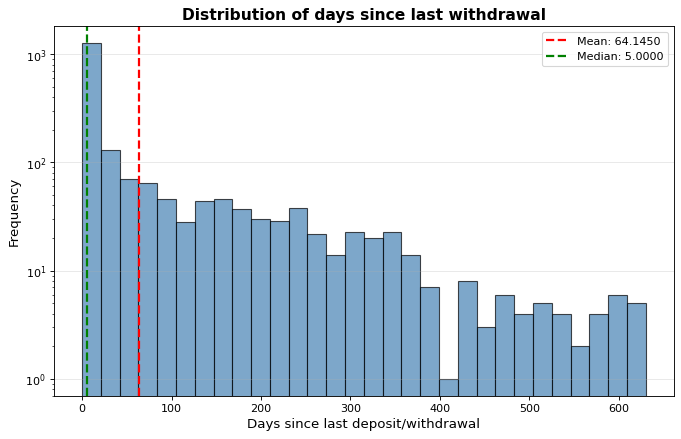

In [39]:
plt.figure(figsize=(10, 6), dpi=80)
ax = plt.gca()

ax.hist(account_summary_date_diff['days_till_2022_12_31'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax.set_xlabel('Days since last deposit/withdrawal', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of days since last withdrawal', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

mean_progress = account_summary_date_diff['days_till_2022_12_31'].mean()
median_progress = account_summary_date_diff['days_till_2022_12_31'].median()
ax.axvline(mean_progress, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_progress:.4f}')
ax.axvline(median_progress, color='green', linestyle='--', linewidth=2, label=f'Median: {median_progress:.4f}')
ax.legend()

#### Random checks

In [40]:
for i in df_raw['accountid'].sample(5):
    print("{:}, days until 2022-12-31: {:}".format(
        i,
        account_summary_date_diff[account_summary_date_diff['accountid'] == i].iloc[0]['days_till_2022_12_31']
    ))

    display(
        df_raw[
            df_raw['accountid'] == i
        ].sort_values(['accountid', 'summary_date'], ascending=True)[['accountid', 'summary_date']][-3:]
    )

668751666, days until 2022-12-31: 0


,accountid,summary_date
289521,668751666,2022-12-31
289556,668751666,2022-12-31
289587,668751666,2022-12-31


668163476, days until 2022-12-31: 6


,accountid,summary_date
505951,668163476,2022-12-24
506099,668163476,2022-12-24
488823,668163476,2022-12-25


668598103, days until 2022-12-31: 5


,accountid,summary_date
212233,668598103,2022-12-26
212301,668598103,2022-12-26
212312,668598103,2022-12-26


667885183, days until 2022-12-31: 190


,accountid,summary_date
459692,667885183,2022-06-20
531572,667885183,2022-06-24
531880,667885183,2022-06-24


667828876, days until 2022-12-31: 7


,accountid,summary_date
518086,667828876,2022-12-23
505017,667828876,2022-12-24
505979,667828876,2022-12-24


#### Charts

In [41]:
account_summary_date_diff.sort_values('days_till_2022_12_31', ascending=True, inplace=True)

In [42]:
account_summary_date_diff['cum_elapsed_days_frequency'] = account_summary_date_diff['days_till_2022_12_31'].cumsum()
account_summary_date_diff['cum_elapsed_days_percentage'] = account_summary_date_diff['cum_elapsed_days_frequency'] / account_summary_date_diff['cum_elapsed_days_frequency'].sum() * 100

In [43]:
account_summary_date_diff['account_frequency'] = 1/account_summary_date_diff.shape[0]
account_summary_date_diff['cum_account_percentage'] = account_summary_date_diff['account_frequency'].cumsum() * 100

In [44]:
account_summary_date_diff[['cum_elapsed_days_percentage', 'cum_account_percentage']][:5]

,cum_elapsed_days_percentage,cum_account_percentage
1999,0.0,0.05
803,0.0,0.10
804,0.0,0.15
805,0.0,0.20
806,0.0,0.25


In [45]:
account_summary_date_diff.columns

Index(['accountid', 'summary_date', 'days_till_2022_12_31',
       'cum_elapsed_days_frequency', 'cum_elapsed_days_percentage',
       'account_frequency', 'cum_account_percentage'],
      dtype='str')

In [46]:
account_summary_date_diff_plot = account_summary_date_diff[['account_frequency', 'days_till_2022_12_31']].sort_values('days_till_2022_12_31', ascending=True)
account_summary_date_diff_plot['cum_account_frequency'] = account_summary_date_diff_plot['account_frequency'].cumsum()

In [47]:
account_summary_date_diff_plot[['account_frequency', 'cum_account_frequency', 'days_till_2022_12_31']][:5]

,account_frequency,cum_account_frequency,days_till_2022_12_31
1999,0.0005,0.0005,0
1226,0.0005,0.0010,0
1224,0.0005,0.0015,0
1223,0.0005,0.0020,0
1216,0.0005,0.0025,0


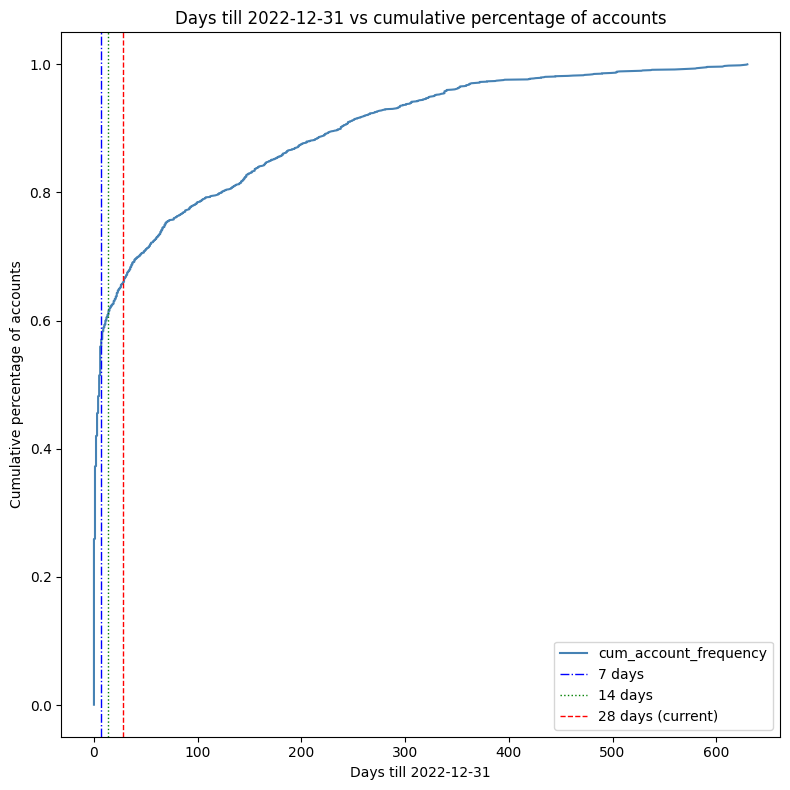

In [48]:
ax = account_summary_date_diff_plot.plot(
    x='days_till_2022_12_31',
    y='cum_account_frequency',
    figsize=(8, 8),
    color='steelblue'
)

ax.set_xlabel('Days till 2022-12-31')
ax.set_ylabel('Cumulative percentage of accounts')
ax.set_title('Days till 2022-12-31 vs cumulative percentage of accounts')
plt.tight_layout()

# add statistics
ax.axvline(7, color='blue', linestyle='-.', linewidth=1, label="7 days")
ax.axvline(14, color='green', linestyle=':', linewidth=1, label="14 days")
ax.axvline(28, color='red', linestyle='--', linewidth=1, label="28 days (current)")
ax.legend()

In [49]:
print("Percentage of accounts at:\n- 7 days: {:.2f}%\n- 14 days: {:.2f}%\n- 28 days: {:.2f}%".format(
    account_summary_date_diff[account_summary_date_diff['days_till_2022_12_31'] < 7]['account_frequency'].sum()*100,
    account_summary_date_diff[account_summary_date_diff['days_till_2022_12_31'] < 14]['account_frequency'].sum()*100,
    account_summary_date_diff[account_summary_date_diff['days_till_2022_12_31'] < 28]['account_frequency'].sum()*100
))

Percentage of accounts at:
- 7 days: 55.95%
- 14 days: 60.90%
- 28 days: 65.75%


#### Answers

In [50]:
# Checking if deposit/withrawal and betcount variables are completely covering the activities (if all those variables are 0, then something is missing)
for i in tqdm(df_raw['accountid'].unique()):
    columns_to_check = ['deposit', 'withdrawal', 'plc_betcount', 'stl_betcount']
    columns_sum = 0
    for k in df_raw[df_raw['accountid'] == i][columns_to_check].index:
        for c in columns_to_check:
            columns_sum += df_raw.loc[k, c]
    
    if columns_sum == 0:
        print("All value fields are zero for {:}".format(i))

100%|██████████| 2000/2000 [00:42<00:00, 47.03it/s]


The __deposit/withdrawal__, __plc_betcount__, and __stl_betcount__ variables (since they represent one logically distinguishable action) are completely covering one user activity
- Columns starting with __plc__ are supposedly for __placed bets__ and belong together
- Columns starting with __stl__ are supposedly for __settled activities__ and belong together

In [51]:
columns_to_check = ['accountid', 'summary_date', 'bet_type', 'category', 'secondary_product', 'foundation_category', 'account_tier', 'activity_channel', 'productgroup']
df_grouped = df_raw[list(columns_to_check) + list(['deposit'])].groupby(columns_to_check, as_index=False).agg({
    'deposit': 'count'
}).rename(columns={'deposit': 'row_count'})

In [52]:
df_grouped[df_grouped['row_count'] > 1][:5]

,accountid,summary_date,bet_type,category,secondary_product,foundation_category,account_tier,activity_channel,productgroup,row_count


The provided table contains no duplicate records when grouped by *accountid*, *summary_date*, *bet_type*, *category*, *secondary_product*, *foundation_category*, *account_tier*, *activity_channel*, and *product_group*, and thus the table is maintained at __daily__ level of granularity.

In [53]:
import datetime

In [54]:
df_raw[
    (df_raw['accountid'] == 667029094) &
    (df_raw['summary_date'] == datetime.date(2022, 12, 25)) &
    (df_raw['bet_type'] == 'RnG') &
    (df_raw['category'] == 'eGaming') &
    (df_raw['secondary_product'] == 'Blackjack') &
    (df_raw['foundation_category'] == 'Plaster') &
    (df_raw['account_tier'] == 'Premium') &
    #(df_raw['ordinalposition'] == 2) &
    (df_raw['activity_channel'] == 'Not Available')
].sort_values('summary_date', ascending=True)[list(['accountid', 'summary_date']) + list(df_raw.columns[10:20])]

,accountid,summary_date,account_tier,ordinalposition,summary_date,category,activity_channel,secondary_product,bet_type,productgroup,plc_turnover_gbp,plc_turnover
489241,667029094,2022-12-25,Premium,2,2022-12-25,eGaming,Not Available,Blackjack,RnG,Casino,2.500000000,2.500000000
489355,667029094,2022-12-25,Premium,2,2022-12-25,eGaming,Not Available,Blackjack,RnG,Live Casino,2.000000000,2.000000000


In [55]:
account_summary_date_diff[:5]

,accountid,summary_date,days_till_2022_12_31,cum_elapsed_days_frequency,cum_elapsed_days_percentage,account_frequency,cum_account_percentage
1999,669169421,2022-12-31,0,0,0.0,0.0005,0.05
803,667931501,2022-12-31,0,0,0.0,0.0005,0.10
804,667931828,2022-12-31,0,0,0.0,0.0005,0.15
805,667932323,2022-12-31,0,0,0.0,0.0005,0.20
806,667932389,2022-12-31,0,0,0.0,0.0005,0.25


In [87]:
rows = []

for i in range(1, 45):
    rows.append({
        'threshold_in_days': i,
        'number_of_accounts': account_summary_date_diff[
            account_summary_date_diff['days_till_2022_12_31'] <= i
        ].shape[0]
    })

df_churn_thresholds = pd.DataFrame(rows)

In [88]:
df_churn_thresholds['percentage_of_accounts'] = df_churn_thresholds['number_of_accounts']/2000*100

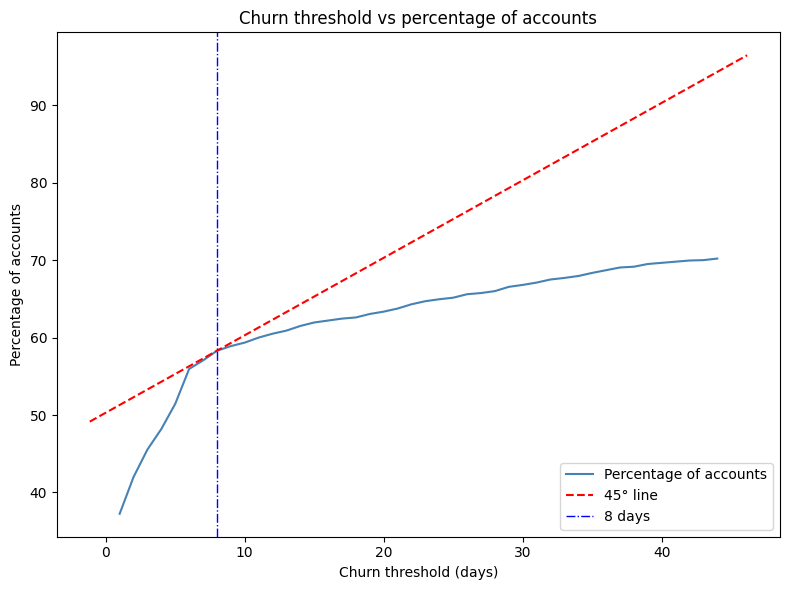

In [100]:
import numpy as np
import matplotlib.pyplot as plt

ax = df_churn_thresholds.plot(
    x='threshold_in_days',
    y='percentage_of_accounts',
    figsize=(8, 6),
    color='steelblue',
    label='Percentage of accounts'
)

# First point
x0 = df_churn_thresholds['threshold_in_days'].iloc[7]
y0 = df_churn_thresholds['percentage_of_accounts'].iloc[7]

# 45-degree line (slope = 1) through the first point
x = np.array(ax.get_xlim())
y = y0 + (x - x0)

ax.plot(x, y, '--', color='red', label='45° line')

ax.axvline(x0, color='blue', linestyle='-.', linewidth=1, label="{:} days".format(x0))

#ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('Churn threshold (days)')
ax.set_ylabel('Percentage of accounts')
ax.set_title('Churn threshold vs percentage of accounts')
ax.legend()

plt.tight_layout()
plt.show()

The following table contains churn thresholds (1 - 45 days) vs percentage of churned accounts (users who never returned (considering until the date of the last activity only))

In [102]:
df_churn_thresholds[:10]

,threshold_in_days,number_of_accounts,percentage_of_accounts
0,1,745,37.25
1,2,840,42.00
2,3,911,45.55
3,4,964,48.20
4,5,1029,51.45
5,6,1119,55.95
6,7,1141,57.05
7,8,1166,58.30
8,9,1178,58.90
9,10,1187,59.35


<div class="alert alert-block alert-info">
    <b>How did you choose to define churn and why?</b><br/>
    The last <i>summary_date</i> for each <i>accountid</i> represents the last day an activity each user has performed.<br/><br/>
    <b>A better definition of churn</b><br/>
    Early churn detection is essential, I would reduce the threshold of days since last action to 8 days
</div>

In [103]:
# Can be set to different values
DAYS_THRESHOLD = 8

In [104]:
account_summary_date_diff['is_churned'] = np.where(
    account_summary_date_diff['days_till_2022_12_31'] <= DAYS_THRESHOLD,
    True,
    False
)

In [105]:
account_summary_date_diff['is_churned'].value_counts(dropna=True)

is_churned
True     1166
False     834
Name: count, dtype: int64

In [106]:
df_data_with_churn = pd.merge(
    df_raw,
    account_summary_date_diff[['accountid', 'is_churned']],
    how='left',
    on='accountid'
)

In [107]:
df_raw.shape, df_data_with_churn.shape

((545488, 53), (545488, 54))

In [108]:
filename = 'output/dataset_churn_labeled_th{:}_{:%Y%m%d}.csv'.format(
    DAYS_THRESHOLD,
    datetime.datetime.now()
)
df_data_with_churn.to_csv(filename, index=False)
print("File saved to `{:}`".format(filename))

File saved to `output/dataset_churn_labeled_th8_20260609.csv`


- How did you choose churn and why?
    - inactivity after 8 days (business perspective, do not nag the customers too much)
    - which features to check? withdrawal/deposit or bet counts only
- Feature engineering
    - What features did I use?
    - What other features shall I use?
    - Check correlation of the features
- Model
    - Build a quick neural network model
    - lasso => feature importance
- Deployment
    - Write down the steps

- Cross check
- Provide what needs to be supplied